# 3. ABC/XYZ анализ ассортимента

## Цели:
- Классификация товаров по вкладу в выручку (ABC)
- Анализ стабильности спроса (XYZ) 
- Построение матрицы ABC-XYZ для стратегических решений
- Рекомендации по управлению ассортиментом

In [5]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')


# Настройка путей
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.abc_xyz_analyzer import ABCXYZAnalyzer

In [6]:
# Загрузка данных
print("ЗАГРУЗКА ДАННЫХ ДЛЯ ABC/XYZ АНАЛИЗА...")
processed_data_path = project_root / 'data' / 'processed' / 'merged_data.csv'

if processed_data_path.exists():
    df = pd.read_csv(processed_data_path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    print(f"Загружено {len(df)} записей, {df['sku'].nunique()} уникальных товаров")
else:
    print("❌ Файл с обработанными данными не найден")


ЗАГРУЗКА ДАННЫХ ДЛЯ ABC/XYZ АНАЛИЗА...
Загружено 2366 записей, 859 уникальных товаров


In [7]:
# Инициализация анализатора
print("ИНИЦИАЛИЗАЦИЯ ABC/XYZ АНАЛИЗАТОРА...")
try:
    analyzer = ABCXYZAnalyzer(df)
    print("✅ Анализатор успешно инициализирован")
except Exception as e:
    print(f"❌ Ошибка инициализации анализатора: {e}")

ИНИЦИАЛИЗАЦИЯ ABC/XYZ АНАЛИЗАТОРА...
✅ Анализатор успешно инициализирован


In [8]:
# 1. ABC АНАЛИЗ
print("\n" + "="*60)
print("ABC АНАЛИЗ - КЛАССИФИКАЦИЯ ПО ВКЛАДУ В ВЫРУЧКУ")
print("="*60)

abc_results = analyzer.abc_analysis(by='revenue')
print(f"Всего проанализировано товаров: {len(abc_results)}")

# Статистика по ABC классам
abc_summary = abc_results.groupby('abc_class').agg({
    'sku': 'count',
    'revenue': 'sum',
    'profit': 'sum',
    'quantity': 'sum'
}).round(2)

abc_summary['revenue_share'] = (abc_summary['revenue'] / abc_summary['revenue'].sum() * 100).round(1)
abc_summary['product_share'] = (abc_summary['sku'] / abc_summary['sku'].sum() * 100).round(1)

print("\nРаспределение по ABC классам:")
print(abc_summary)


ABC АНАЛИЗ - КЛАССИФИКАЦИЯ ПО ВКЛАДУ В ВЫРУЧКУ
Всего проанализировано товаров: 859

Распределение по ABC классам:
           sku  revenue       profit  quantity  revenue_share  product_share
abc_class                                                                   
A          435  9360806  12783687.13      3881           79.9           50.6
B          238  1762795   2360634.62      1268           15.1           27.7
C          186   587122    718956.52       792            5.0           21.7


In [9]:
# 2. XYZ АНАЛИЗ
print("\n" + "="*60)
print("XYZ АНАЛИЗ - АНАЛИЗ СТАБИЛЬНОСТИ СПРОСА")
print("="*60)

xyz_results = analyzer.xyz_analysis(period='month')
print(f"Проанализировано товаров для XYZ: {len(xyz_results)}")

# Статистика по XYZ классам
xyz_summary = xyz_results.groupby('xyz_class').agg({
    'sku': 'count',
    'cv': 'mean'
}).round(3)

xyz_summary['product_share'] = (xyz_summary['sku'] / xyz_summary['sku'].sum() * 100).round(1)

print("\nРаспределение по XYZ классам:")
print(xyz_summary)


XYZ АНАЛИЗ - АНАЛИЗ СТАБИЛЬНОСТИ СПРОСА
Период данных: 270 дней
Уникальных периодов: 9
Товаров для анализа: 859
Товаров с достаточными данными: 353

Распределение по XYZ классам:
  X: 0 товаров (0.0%)
  Y: 0 товаров (0.0%)
  Z: 859 товаров (100.0%)
Проанализировано товаров для XYZ: 859

Распределение по XYZ классам:
period     sku     cv  product_share
xyz_class                           
Z          859  1.217          100.0


In [10]:
# 3. МАТРИЦА ABC-XYZ
print("\n" + "="*60)
print("МАТРИЦА ABC-XYZ - КОМБИНИРОВАННЫЙ АНАЛИЗ")
print("="*60)

matrix = analyzer.create_abc_xyz_matrix()
print(f"Создана матрица для {len(matrix)} товаров")

# Общая статистика матрицы
matrix_summary = analyzer.get_strategic_recommendations()
print("\nСводка по матрице ABC-XYZ:")
print(matrix_summary)



МАТРИЦА ABC-XYZ - КОМБИНИРОВАННЫЙ АНАЛИЗ
Период данных: 270 дней
Уникальных периодов: 9
Товаров для анализа: 859
Товаров с достаточными данными: 353

Распределение по XYZ классам:
  X: 0 товаров (0.0%)
  Y: 0 товаров (0.0%)
  Z: 859 товаров (100.0%)
Создана матрица для 859 товаров

Сводка по матрице ABC-XYZ:
               sku  revenue       profit  revenue_share  \
abc_xyz_class                                             
AZ             435  9360806  12783687.13           79.9   
BZ             238  1762795   2360634.62           15.1   
CZ             186   587122    718956.52            5.0   

                                                  recommendation  
abc_xyz_class                                                     
AZ             ⚡ ВОПРОСЫ - Товары с потенциалом. Изучить прич...  
BZ             ⚠ РИСКОВАННЫЕ - Нестабильные середняки. Контро...  
CZ             ❌ ПРОБЛЕМНЫЕ - Кандидаты на исключение. Рассмо...  



ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ABC-XYZ


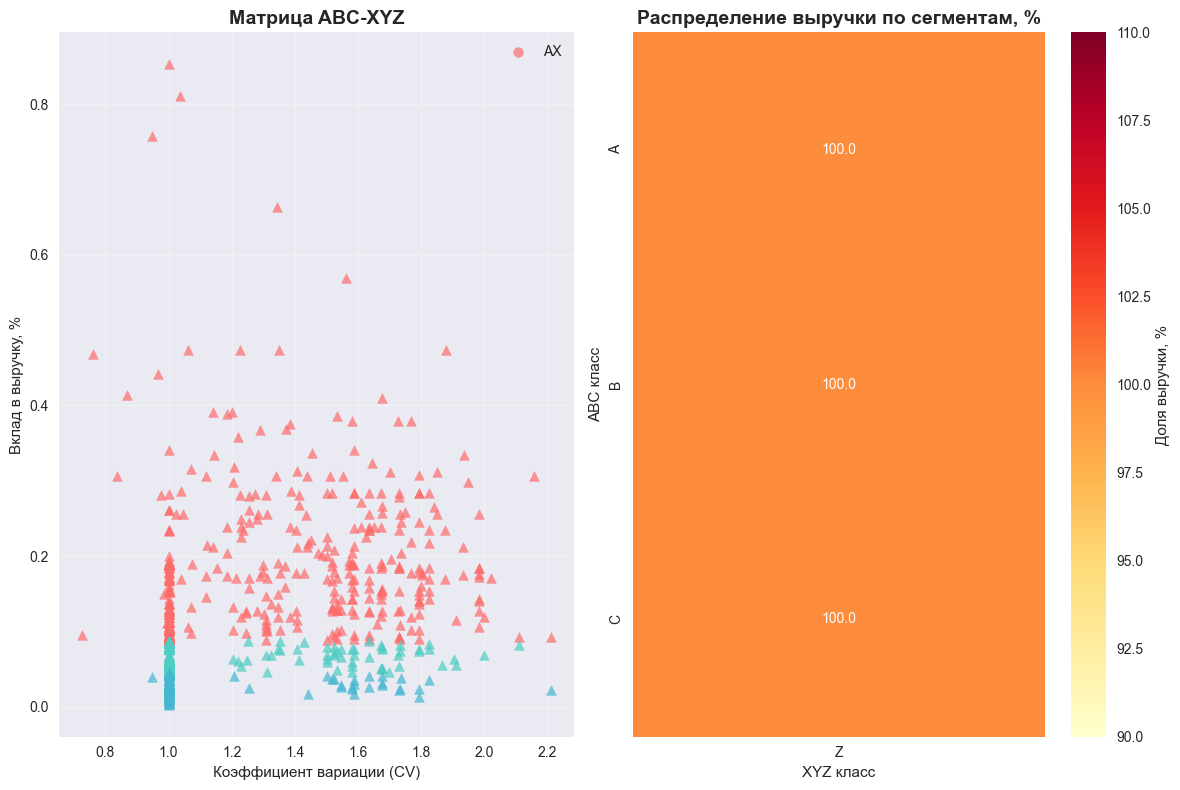

In [11]:
# 4. ВИЗУАЛИЗАЦИЯ МАТРИЦЫ
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ABC-XYZ")
print("="*60)

analyzer.plot_abc_xyz_matrix()

In [12]:
# 5. СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ
print("\n" + "="*60)
print("СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ")
print("="*60)

# Рекомендации по товарам
product_recommendations = analyzer.get_product_recommendations(top_n=15)
print("\nТоп-15 товаров с рекомендациями:")
print(product_recommendations.to_string(index=False))


СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ

Топ-15 товаров с рекомендациями:
              sku      Бренд Категория abc_class xyz_class abc_xyz_class  revenue  percent_contribution       cv                 recommendation
   FFF_Clear_4303      KZDOO     Чехлы         A         Z            AZ    99900              0.008531 1.000000 Изучить причины нестабильности
    HHH_Pink_2327      KZDOO     Чехлы         A         Z            AZ    95040              0.008116 1.037346 Изучить причины нестабильности
  FFF_Purple_9422 Неизвестно     Чехлы         A         Z            AZ    88800              0.007583 0.948683 Изучить причины нестабильности
   BBB_White_3663      KZDOO     Чехлы         A         Z            AZ    77700              0.006635 1.343026 Изучить причины нестабильности
    CCC_Pink_8383      KZDOO     Чехлы         A         Z            AZ    66600              0.005687 1.560311 Изучить причины нестабильности
FFF_Titanium_1822      KZDOO     Чехлы         A         Z            AZ 

In [13]:
# 6. ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ")
print("="*60)

# Анализ звезд (AX)
stars = matrix[matrix['abc_xyz_class'] == 'AX']
if not stars.empty:
    print(f"\n🌟 ЗВЕЗДЫ (AX) - {len(stars)} товаров:")
    print(stars[['sku', 'Бренд', 'Категория', 'revenue', 'percent_contribution']].to_string(index=False))

# Анализ проблемных товаров (CZ)
problems = matrix[matrix['abc_xyz_class'] == 'CZ']
if not problems.empty:
    print(f"\n❌ ПРОБЛЕМНЫЕ (CZ) - {len(problems)} товаров:")
    print(problems[['sku', 'Бренд', 'Категория', 'revenue', 'cv']].to_string(index=False))



ДЕТАЛЬНЫЙ АНАЛИЗ КЛЮЧЕВЫХ СЕГМЕНТОВ

❌ ПРОБЛЕМНЫЕ (CZ) - 186 товаров:
              sku      Бренд                Категория  revenue       cv
    GGG_Pink_2598      KZDOO                    Чехлы     5300 1.000000
   FFF_Clear_8370   KEEPHONE                    Чехлы     5300 1.000000
   GGG_Green_1753   KEEPHONE                    Чехлы     5200 1.000000
   GGG_Green_7035    Robiton Батарейки и аккумуляторы     5200 1.000000
FFF_Titanium_5998   KEEPHONE                    Чехлы     5200 1.000000
    DDD_Pink_2219   KEEPHONE                    Чехлы     5200 1.000000
   HHH_Green_2539      KZDOO                    Чехлы     5180 1.000000
    AAA_Pink_5462      KZDOO                    Чехлы     5180 1.000000
  FFF_Purple_8028      KZDOO                    Чехлы     5160 1.000000
   AAA_Black_1398      K-DOO                    Чехлы     5160 1.000000
   HHH_Black_4644   KEEPHONE                    Чехлы     5100 1.000000
EEE_Titanium_7841      KZDOO                    Чехлы     5100 1.

In [14]:
# 7. АНАЛИЗ ПО БРЕНДАМ И КАТЕГОРИЯМ
print("\n" + "="*60)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПО БРЕНДАМ И КАТЕГОРИЯМ")
print("="*60)

if 'Бренд' in matrix.columns:
    brand_analysis = matrix.groupby(['Бренд', 'abc_class']).agg({
        'sku': 'count',
        'revenue': 'sum'
    }).round(2)
    
    brand_analysis_pivot = brand_analysis['revenue'].unstack(fill_value=0)
    brand_analysis_pivot['total'] = brand_analysis_pivot.sum(axis=1)
    brand_analysis_pivot = brand_analysis_pivot.sort_values('total', ascending=False)
    
    print("\nРаспределение выручки по брендам и ABC классам:")
    print(brand_analysis_pivot.head(10))


АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПО БРЕНДАМ И КАТЕГОРИЯМ

Распределение выручки по брендам и ABC классам:
abc_class         A        B       C    total
Бренд                                        
KZDOO       7072652  1188518  313868  8575038
KEEPHONE    1381078   293737   69134  1743949
K-DOO        476104    86110   38810   601024
Robiton      156430    63720   76100   296250
Неизвестно   188460    18200       0   206660
REMAX         25532    59520   37400   122452
Нет бренда    17970    37090   21170    76230
Raigor        31080        0       0    31080
Renata        11500        0   14420    25920
Varta             0     6900   15000    21900


In [15]:
# 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n" + "="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ABC/XYZ АНАЛИЗА")
print("="*60)

# Создаем папку для отчетов
abcxyz_report_path = project_root / 'reports' / 'abc_xyz'
abcxyz_report_path.mkdir(parents=True, exist_ok=True)

# Сохраняем результаты
matrix.to_csv(abcxyz_report_path / 'abc_xyz_matrix.csv', index=False)
print("✓ Сохранена матрица ABC-XYZ")

abc_results.to_csv(abcxyz_report_path / 'abc_analysis.csv', index=False)
print("✓ Сохранен ABC анализ")

xyz_results.to_csv(abcxyz_report_path / 'xyz_analysis.csv', index=False)
print("✓ Сохранен XYZ анализ")

product_recommendations.to_csv(abcxyz_report_path / 'product_recommendations.csv', index=False)
print("✓ Сохранены рекомендации по товарам")


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ABC/XYZ АНАЛИЗА
✓ Сохранена матрица ABC-XYZ
✓ Сохранен ABC анализ
✓ Сохранен XYZ анализ
✓ Сохранены рекомендации по товарам


In [16]:
# 9. БИЗНЕС-ВЫВОДЫ
print("\n" + "="*60)
print("КЛЮЧЕВЫЕ БИЗНЕС-ВЫВОДЫ")
print("="*60)

total_products = len(matrix)
total_revenue = matrix['revenue'].sum()

# Анализ концентрации
top_a = matrix[matrix['abc_class'] == 'A']
top_ax = matrix[matrix['abc_xyz_class'] == 'AX']

print(f"📊 ОБЩАЯ СТАТИСТИКА:")
print(f"  • Всего товаров: {total_products}")
print(f"  • Товары класса A: {len(top_a)} ({len(top_a)/total_products*100:.1f}%)")
print(f"  • Выручка от класса A: {top_a['revenue'].sum():,.0f} ₽ ({top_a['revenue'].sum()/total_revenue*100:.1f}%)")
print(f"  • Звезды (AX): {len(top_ax)} товаров")

print(f"\n🎯 РЕКОМЕНДАЦИИ:")
print(f"  • Сфокусироваться на {len(top_a)} товарах класса A")
print(f"  • Оптимизировать запасы {len(top_ax)} звездных товаров")
print(f"  • Проанализировать {len(problems)} проблемных товаров на исключение")


КЛЮЧЕВЫЕ БИЗНЕС-ВЫВОДЫ
📊 ОБЩАЯ СТАТИСТИКА:
  • Всего товаров: 859
  • Товары класса A: 435 (50.6%)
  • Выручка от класса A: 9,360,806 ₽ (79.9%)
  • Звезды (AX): 0 товаров

🎯 РЕКОМЕНДАЦИИ:
  • Сфокусироваться на 435 товарах класса A
  • Оптимизировать запасы 0 звездных товаров
  • Проанализировать 186 проблемных товаров на исключение


In [17]:
print("\n✅ ABC/XYZ АНАЛИЗ ЗАВЕРШЕН!")
print("📊 Создана стратегическая матрица ассортимента")
print("📁 Сохранены отчеты в /reports/abc_xyz/")


✅ ABC/XYZ АНАЛИЗ ЗАВЕРШЕН!
📊 Создана стратегическая матрица ассортимента
📁 Сохранены отчеты в /reports/abc_xyz/
